# Map of $R_{\rho}$ (density ratio or stability ratio)

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import warnings
import s3fs
import matplotlib
import gsw

In [2]:
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [3]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:36459")
client

<Client: 'tcp://127.0.0.1:36459' processes=8 threads=32, memory=123.95 GiB>

## Open Datasets

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

In [6]:
# initialize s3 filesystem
# for sassie s3 bucket
# s3_options = dict(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)
# for ecco s3 bucket
s3_options = dict(anon=False)

In [8]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [11]:
# open SALT zarr store - [psu]
SALT_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_MONTHLY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_MONTHLY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_MONTHLY.ZARR/', s3_options)

In [12]:
# remove 2021 since we only have January and a few days in Feb
salt_month = SALT_zarr.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_month = THETA_zarr.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_month = SI_zarr.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)

In [17]:
# select one month to start
salt_month = SALT_zarr.SALT.sel(time=("2019-08-15"))
theta_month = THETA_zarr.THETA.sel(time=("2019-08-15"))
ice_month = SI_zarr.SIarea.sel(time=("2019-08-15"))

## Calculate Rsubrho

Rsubrho calculation using gsw package:<br>
https://www.teos-10.org/pubs/gsw/html/gsw_Turner_Rsubrho.html

In [18]:
# pressure from depth
# Z needs to be positive up
pressure_da = gsw.p_from_z(HH_grid.isel(k=slice(0,22)).Z, HH_grid.YC).compute()

In [19]:
# just double check to make sure they look reasonable
pressure_da.isel(i=10,j=10).values

array([  0.50428623,   1.58346296,   2.8139329 ,   4.22091377,
         5.82962441,   7.66024071,   9.74302836,  12.1132969 ,
        14.80635815,  17.85752767,  21.30716931,  25.20573703,
        29.59864862,  34.53637577,  40.06938752,  46.25322558,
        53.14847207,  60.80564481,  69.28536079,  78.64826011,
        88.94996626, 100.246103  ])

In [20]:
# Calculates Absolute Salinity from Practical Salinity
SA = gsw.SA_from_SP(salt_month, pressure_da, HH_grid.XC, HH_grid.YC)

In [21]:
# Calculates Conservative Temperature of seawater from potential temperature (whose reference sea pressure is zero dbar)
CT = gsw.CT_from_pt(SA, theta_month)

In [22]:
print(SA.shape)
print(CT.shape)
print(pressure_da.shape)

(22, 1080, 1800)
(22, 1080, 1800)
(22, 1080, 1800)


In [23]:
[Tu, Rsubrho, p_mid] = gsw.Turner_Rsubrho(SA,CT,pressure_da)

In [24]:
np.shape(Rsubrho)

(21, 1080, 1800)

In [25]:
Rsubrho_snapshot = xr.DataArray(Rsubrho, coords=[p_mid[:,1000,1000], salt_month.j, salt_month.i],\
                                dims=["pressure", "j", "i"],\
                                name="Rsubrho", attrs={"units": "dimensionless"})

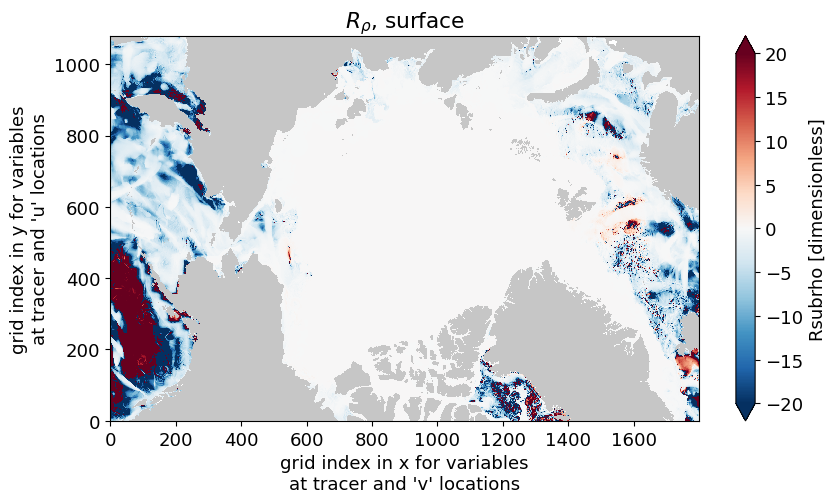

In [26]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=[9.5,5])
Rsubrho_snapshot.isel(pressure=0).plot(ax=ax,vmin=-20,vmax=20,cmap='RdBu_r');
HH_grid_land.plot(ax=ax,vmin=-1,vmax=2,cmap='Greys',add_colorbar=False);
ax.set_title(r'$R_\rho$, surface');

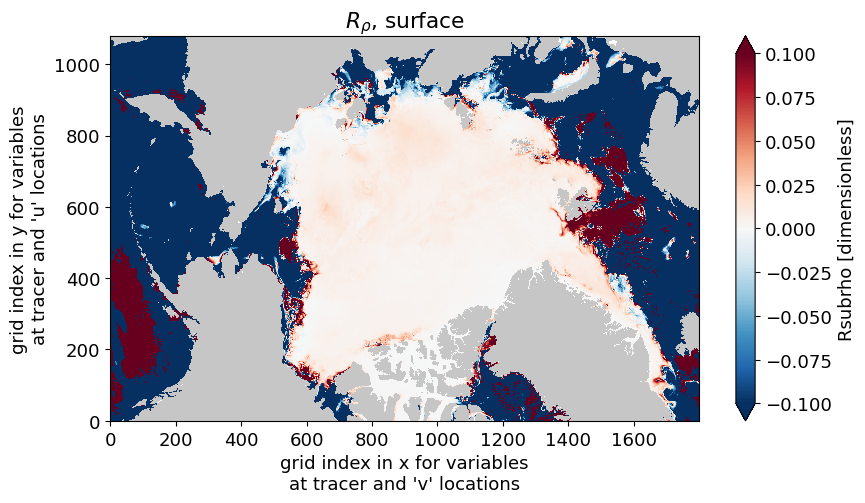

In [27]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=[9.5,5])
Rsubrho_snapshot.isel(pressure=0).plot(ax=ax,vmin=-1e-1,vmax=1e-1,cmap='RdBu_r');
HH_grid_land.plot(ax=ax,vmin=-1,vmax=2,cmap='Greys',add_colorbar=False);
ax.set_title(r'$R_\rho$, surface');

In [28]:
Rsubrho_snapshot.isel(pressure=9).pressure.values

array(19.61950415)

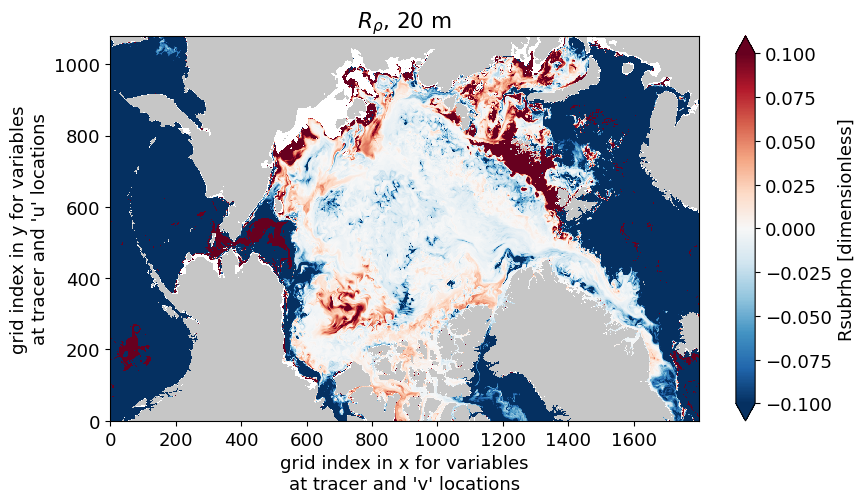

In [29]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=[9.5,5])
Rsubrho_snapshot.isel(pressure=9).plot(ax=ax,vmin=-0.1,vmax=0.1,cmap='RdBu_r');
HH_grid_land.plot(ax=ax,vmin=-1,vmax=2,cmap='Greys',add_colorbar=False);
ax.set_title(r'$R_\rho$, 20 m');

In [30]:
Rsubrho_snapshot.isel(pressure=20).pressure.values

array(94.77755678)

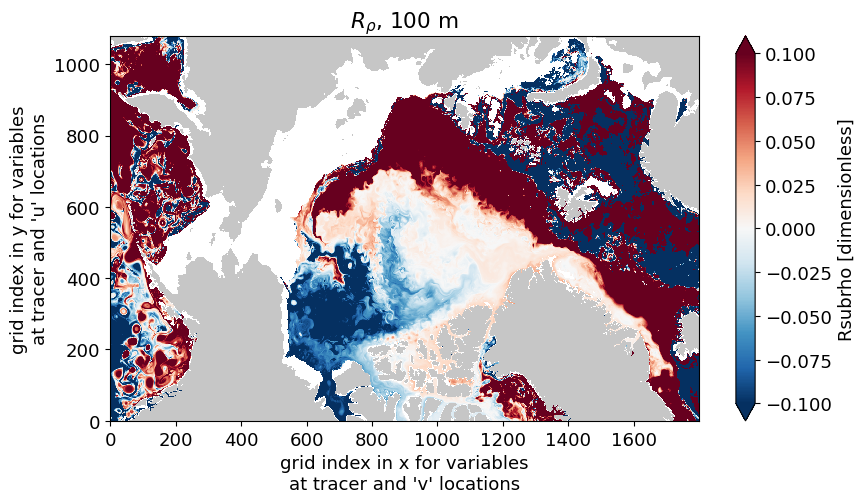

In [31]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=[9.5,5])
Rsubrho_snapshot.isel(pressure=20).plot(ax=ax,vmin=-0.1,vmax=0.1,cmap='RdBu_r');
HH_grid_land.plot(ax=ax,vmin=-1,vmax=2,cmap='Greys',add_colorbar=False);
ax.set_title(r'$R_\rho$, 100 m');